In [45]:
import sys
import os
from pathlib import Path
from langchain_core.messages import AIMessage, HumanMessage,SystemMessage
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
import streamlit as st
from typing import Annotated
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv
from utils.web_search_tool import google_search
from utils.rag_web_base_loader_tool import web_loader_tool
from utils.finance_law import finance_law_tool
from utils.tax import CGI_tool
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from utils.cgnc import cgnc_tool
from utils.plan_comptable import plan_comptable_tool

In [46]:
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
MODELS="openai/gpt-oss-120b"
llm_groq=ChatGroq(model=MODELS)

In [47]:
class State(TypedDict):
    messages:Annotated[list,add_messages]


tools=[cgnc_tool,google_search,web_loader_tool,finance_law_tool,CGI_tool,plan_comptable_tool]
#tools=[google_search]
llm_with_tools=llm_groq.bind_tools(tools)

def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

In [48]:
rules_1="""TOOL SELECTION RULES:
- Moroccan accounting, CGNC, chart of accounts, balance sheet, amortissement → use 'code_general_normalisation_comptable_maroc'
- Tax questions, IS, IR, TVA, CGI → use 'code_general_des_impots_morocco'
- Annual budget law, loi de finances, yearly fiscal changes → use 'loi_de_finances_maroc'
- Account numbers, specific account codes, journal entries → use 'plan_comptable_general_marocain'
- Current news, recent events, non-accounting questions → use 'google_search'
- Load a webpage or URL → use 'rag_web_loader'"""

rules_2="""always follow to tools descriptions and instructions to select the right tool for the user question. 
If the question is not clear, use google search to find more information about the topic and then select the right tool to answer the question.
 Always use a tool before answering. Never answer accounting or tax questions from memory alone."""

rules_3="use google search to answer enything the user said "

In [90]:
def tool_calling_llm(state: State):
    system_message = SystemMessage(content=f"""You are a Moroccan accounting expert assistant.
                                   {rules_2}
                                    Always use a tool before answering. Never answer accounting or tax questions from memory alone.
""")
    all_messages = [system_message] + state["messages"]
    return {"messages": [llm_with_tools.invoke(all_messages)][-3:]}

In [91]:
source_instruction_1 = {
        "code_general_normalisation_comptable_maroc": "Format as professional accounting advice. Mention this comes from CGNC standards.",
        "code_general_des_impots_morocco": "Format as professional tax advice. Mention this comes from the Code Général des Impôts.",
        "loi_de_finances_maroc": "Format clearly with the fiscal year context. Mention this comes from the Loi de Finances.",
        "plan_comptable_general_marocain": "Present account numbers and journal entries in a clear tabular format.",
        "google_search": 'Cite the source as "Web Search". Present information clearly.',
        "rag_web_loader": "Summarize the webpage content clearly.",
        
    }
source_instruction_2 ="use the tools to solve user probleme asa accountant expert"

source_instruction_3 = {
        "code_general_normalisation_comptable_maroc": "Format as professional accounting advice. Mention this comes from CGNC standards. you must combine this with plan_comptable_general_marocain",
        "code_general_des_impots_morocco": "Format as professional tax advice. Mention this comes from the Code Général des Impôts.",
        "loi_de_finances_maroc": "Format clearly with the fiscal year context. Mention this comes from the Loi de Finances.",
        "plan_comptable_general_marocain": "Present account numbers and journal entries in a clear tabular format. you must combine this with code_general_normalisation_comptable_maroc",
        "google_search": 'Cite the source as "Web Search". Present information clearly.',
        "rag_web_loader": "Summarize the webpage content clearly.",
        
    }

In [92]:
def agent_structuring_response(state: State):
    # Find the last ToolMessage to know which tool was used
    system_message = SystemMessage(content=f"""You are a response structuring assistant.

                Instructions: {source_instruction_3}

                if you feel that you need to reuse the tools multiple time reuse multiple tools .
                
                If the response content is empty or unclear, say: "I couldn't find specific information on this topic. Try rephrasing your question."

                Do not add information that wasn't in the original response. Just structure and format it.
                """)

    all_messages = [system_message] + state["messages"]
    return {"messages": [llm_with_tools.invoke(all_messages)]}

In [93]:
graph = StateGraph(State)
graph.add_node("tool_calling_llm", tool_calling_llm)
graph.add_node("tools", ToolNode(tools))
graph.add_node("structures", agent_structuring_response)
graph.add_edge(START, "tool_calling_llm")
graph.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)
graph.add_edge("tools", "structures")
graph.add_conditional_edges(
    "structures",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)

# Compile
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Compile the graph with memory
config = {"configurable": {"thread_id": "AAA"}}

graph_builder = graph.compile(checkpointer=memory)

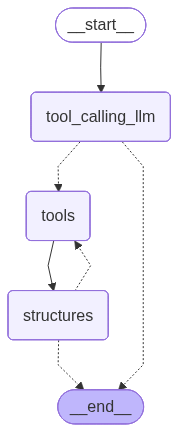

In [94]:

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END


# View
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [95]:
text=""" 
   NoxTools Invoice Number: XWFM4/1 Date: 10 Apr 2026 NoxTools Group Buy Email :- noxtoolshelp@gmail.com ilias baher
   miiliab123@gmail.com Subscription/Product TitleUdemy BusinesBegin10 Apr 2026Expire10 May 2026#Qty1.Subscription/Product TitleUdemy Business1Unit Price499.00 INRTotal Price499.00 INRTotal499.00 INRSubscription Terms: 499.00 INR for one month
"""

In [96]:
test_message = "comptabilise cette facture "
# Button to run test
if test_message:
    file_content = text

            
    if file_content:
                # Combine file content with the query
         enhanced_query = f"""Here is the file uploaded content: {file_content} , User query: {test_message}"""
    else:
        enhanced_query = test_message
                
    result = graph_builder.invoke(
                {'messages': HumanMessage(content=enhanced_query)}, 
                config=config
                )
                
                # Checking tool calling if and else

   

In [97]:
result

{'messages': [HumanMessage(content='Here is the file uploaded content:  \n   NoxTools Invoice Number: XWFM4/1 Date: 10 Apr 2026 NoxTools Group Buy Email :- noxtoolshelp@gmail.com ilias baher\n   miiliab123@gmail.com Subscription/Product TitleUdemy BusinesBegin10 Apr 2026Expire10 May 2026#Qty1.Subscription/Product TitleUdemy Business1Unit Price499.00 INRTotal Price499.00 INRTotal499.00 INRSubscription Terms: 499.00 INR for one month\n , User query: comptabilise cette facture ', additional_kwargs={}, response_metadata={}, id='1db2cb10-beaa-4dc8-81a3-95132b480af8'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to "comptabilise cette facture" (record this invoice) in Moroccan accounting. Need to provide journal entry. Need appropriate account numbers from PCGM. Should use plan_comptable_general_marocain tool to get exact accounts for subscription expense (service purchase), VAT? The invoice is in INR, but likely need to convert to MAD. Not specified. Provide 

In [98]:
for mesage in result["messages"]:
    for i in mesage:
        print(i)
        print("___________________________________________________________________")
    print("###############################################################")

('content', 'Here is the file uploaded content:  \n   NoxTools Invoice Number: XWFM4/1 Date: 10 Apr 2026 NoxTools Group Buy Email :- noxtoolshelp@gmail.com ilias baher\n   miiliab123@gmail.com Subscription/Product TitleUdemy BusinesBegin10 Apr 2026Expire10 May 2026#Qty1.Subscription/Product TitleUdemy Business1Unit Price499.00 INRTotal Price499.00 INRTotal499.00 INRSubscription Terms: 499.00 INR for one month\n , User query: comptabilise cette facture ')
___________________________________________________________________
('additional_kwargs', {})
___________________________________________________________________
('response_metadata', {})
___________________________________________________________________
('type', 'human')
___________________________________________________________________
('name', None)
___________________________________________________________________
('id', '1db2cb10-beaa-4dc8-81a3-95132b480af8')
___________________________________________________________________
#

In [99]:
text=""
len(text)

0

In [100]:
if result["messages"][1].tool_calls:

    for tool_call in result["messages"][1].tool_calls:
        print(f"the source: {tool_call['name']} ")
                    
        print(f"Response: 📝 {result['messages'][-1].content}")
else:
    print(f"the source: LLM (no tools used) ")
    print(f"Response: 📝 {result['messages'][-1].content}")
            

the source: plan_comptable_general_marocain 
Response: 📝 **Comptabilisation de la facture « Udemy Business » – 499 INR**  
*(conformément au *Code Général de Normalisation Comptable* (CGNC) et au *Plan Comptable Général Marocain* (PCGM))*  

| Date | Numéro de pièce | **Compte** (numéro – libellé) | Débit | Crédit |
|------|----------------|--------------------------------|-------|--------|
| 10 /04 /2026 | Facture NoxTools XWFM4/1 | **3421 – Clients** | 499 INR | |
| 10 /04 /2026 | Facture NoxTools XWFM4/1 | **71253 – Prestations de services** | | 499 INR |

*Lorsque le règlement est reçu (virement, chèque, etc.)*  

| Date | Numéro de pièce | **Compte** (numéro – libellé) | Débit | Crédit |
|------|----------------|--------------------------------|-------|--------|
| … | Règlement client | **5141 – Banque** | 499 INR | |
| … | Règlement client | **3421 – Clients** | | 499 INR |

---

### Points clés du traitement (CGNC)

| Aspect | Référence CGNC | Application |
|--------|-----------

In [101]:
from langchain_community.utilities import SerpAPIWrapper
from dotenv import load_dotenv
import os
from langchain_core.tools import Tool
from langchain.tools import tool
#load_dotenv()
#serpapi_key = os.getenv("SERPAPI_API_KEY")


#os.environ["SERPAPI_API_KEY"] = serpapi_key


serpapi_key="77b5c56c9561a90537a44313904fad032f773567630814582bcac8de56b5d7e2"
if not serpapi_key:
    raise ValueError(
        "SERPAPI_API_KEY environment variable is not set. "
        "Please set it in your .env file or pass it as an environment variable."
    )
search_wrapper = SerpAPIWrapper(serpapi_api_key=serpapi_key)


In [102]:
search_wrapper.run("who is the current king of morocco ?")

'["Mohammed VI is King of Morocco. A member of the Alawi dynasty, he has reigned since 1999. Mohammed VI. Amir al-Mu\'minin. Mohammed in 2022. King of Morocco.", \'The current king of Morocco is Mohammed VI (Sidi Mohammed bin Hassan al-Alawi), who ascended the throne on 23 July 1999 following the death of his father, ...\', \'Muḥammad VI (born August 21, 1963, Rabat, Morocco) is the king of Morocco since 1999. Muḥammad ibn al-Ḥasan completed primary and secondary schooling at the ...\', "\'The Enigma of Mohammed VI\' (1/6). Twenty-six years after his 1999 coronation, the Moroccan monarch\'s relationship to power remains complex.", \'HM King Mohammed VI is Supreme Commander and Chief of the General Staff of the Royal Armed Forces (FAR). His first foreign trip since his enthronement was from ...\', \'The current king of Morocco, Mohammed VI, was born in Rabat, Morocco on August 21, 1963. His parents were King Hassan II, and his wife, ...\', \'His Majesty King Mohammed VI, held, today, at